Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import quote_plus
from sqlalchemy import create_engine

Connect Python to PostgreSQL

In [2]:
username = "postgres"
password = quote_plus("C0ncentr@te")
host = "localhost"
port = "5433"
database = "ecommerce_analysis"

engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

print("Database connected successfully!")

Database connected successfully!


Load Orders Table

In [3]:
orders = pd.read_sql("SELECT * FROM orders", engine)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


Load Customers Table

In [4]:
customers = pd.read_sql("SELECT * FROM customers", engine)

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Load Payments Table

In [5]:
payments = pd.read_sql("SELECT * FROM payments", engine)

payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Load Order Items

In [6]:
order_items = pd.read_sql("SELECT * FROM order_items", engine)

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Understand Dataset

Check rows and columns:

In [7]:
orders.shape

(99441, 8)

Check Column Names

In [8]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

Check Missing Values

In [9]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Check Duplicate Records

In [11]:
orders.duplicated().sum()

np.int64(0)

Convert Date Columns

In [12]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

Monthly Revenue Analysis

Merge Tables

In [13]:
merged_df = orders.merge(
    payments,
    on='order_id'
)

In [14]:
merged_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,credit_card,3,179.12


Create new column

In [15]:
merged_df['month'] = merged_df[
    'order_purchase_timestamp'
].dt.to_period('M')

In [16]:
merged_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,credit_card,1,18.12,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3,voucher,1,2.00,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2,voucher,1,18.59,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,boleto,1,141.46,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,credit_card,3,179.12,2018-08


Monthly Revenue

In [17]:
monthly_revenue = merged_df.groupby('month')[
    'payment_value'
].sum()

In [18]:
monthly_revenue.head()

month
2016-09       252.24
2016-10     59090.48
2016-12        19.62
2017-01    138488.04
2017-02    291908.01
Freq: M, Name: payment_value, dtype: float64

Plot Revenue Trend

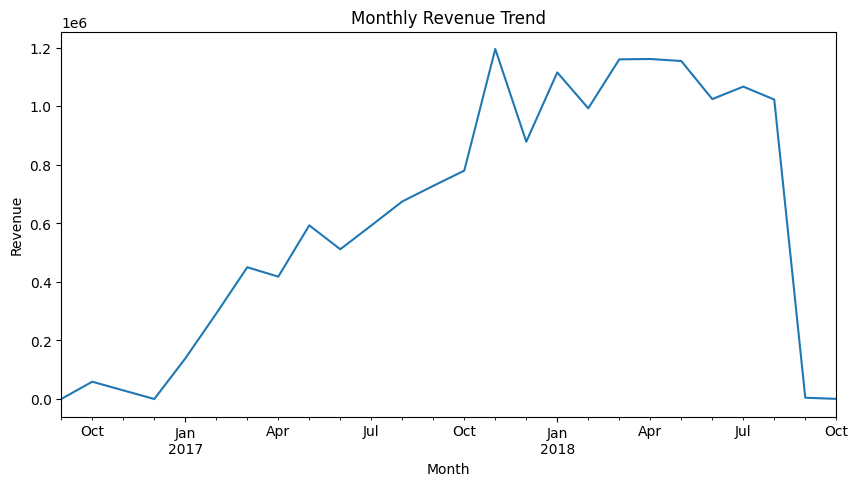

In [19]:
monthly_revenue.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Top Payment Types

In [20]:
payments.groupby('payment_type')[
    'payment_value'
].sum().sort_values(ascending=False)

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

Visualization

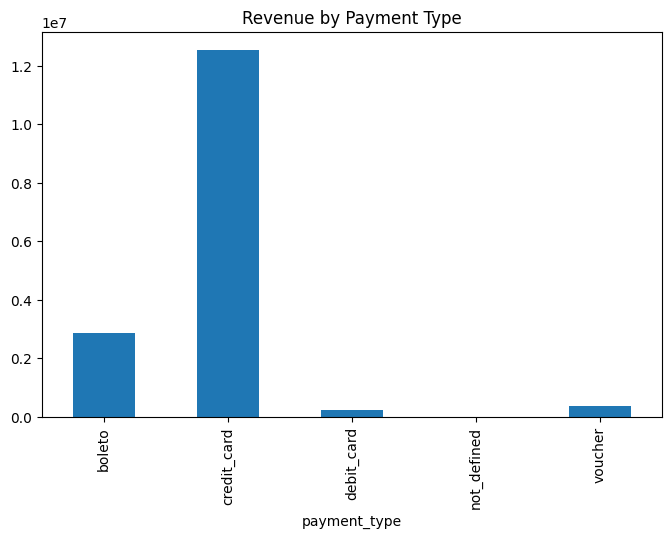

In [21]:
payments.groupby('payment_type')[
    'payment_value'
].sum().plot(kind='bar', figsize=(8,5))

plt.title("Revenue by Payment Type")

plt.show()

Top States by Revenue



Merge Customer + Orders + Payments

In [22]:
customer_orders = customers.merge(
    orders,
    on='customer_id'
)

customer_orders = customer_orders.merge(
    payments,
    on='order_id'
)

Revenue by State

In [23]:
state_revenue = customer_orders.groupby(
    'customer_state'
)['payment_value'].sum().sort_values(ascending=False)

state_revenue.head(10)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: payment_value, dtype: float64

Plot

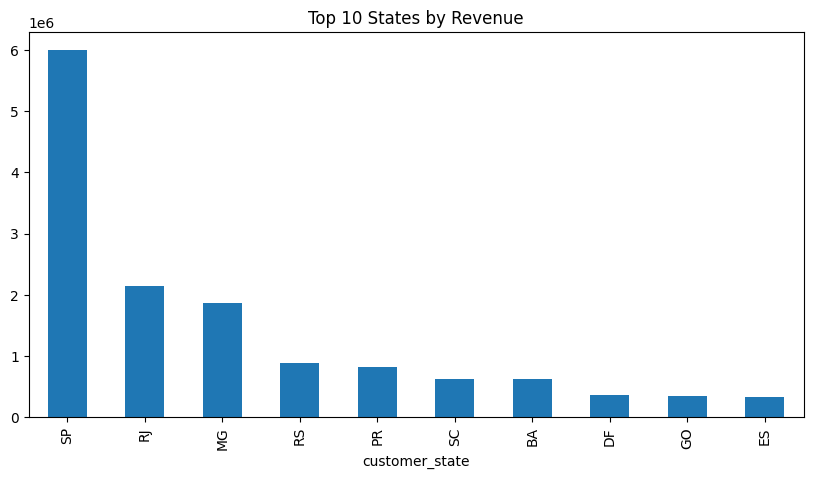

In [24]:
state_revenue.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 States by Revenue")

plt.show()

Delivery Time Analysis

In [25]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

Average Delivery Days

In [26]:
orders['delivery_days'].mean()

np.float64(12.094085575687217)

Distribution Plot

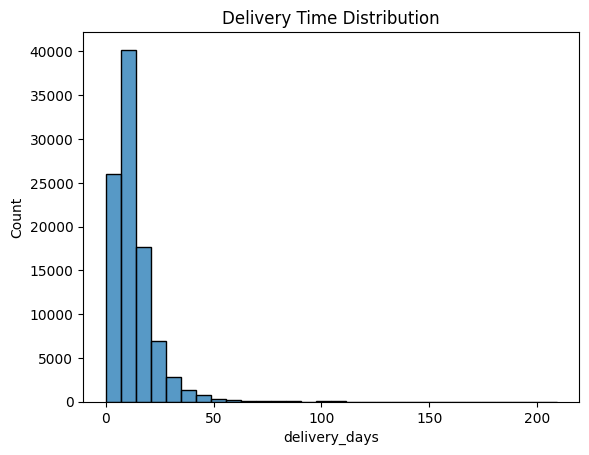

In [27]:
sns.histplot(
    orders['delivery_days'].dropna(),
    bins=30
)

plt.title("Delivery Time Distribution")

plt.show()

Top Customers

In [28]:
top_customers = customer_orders.groupby(
    'customer_id'
)['payment_value'].sum().sort_values(ascending=False)

top_customers.head(10)

customer_id
1617b1357756262bfa56ab541c47bc16    13664.08
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
f48d464a0baaea338cb25f816991ab1f     6922.21
3fd6777bbce08a352fddd04e4a7cc8f6     6726.66
05455dfa7cd02f13d132aa7a6a9729c6     6081.54
df55c14d1476a9a3467f131269c2477f     4950.34
e0a2412720e9ea4f26c1ac985f6a7358     4809.44
24bbf5fd2f2e1b359ee7de94defc4a15     4764.34
3d979689f636322c62418b6346b1c6d2     4681.78
Name: payment_value, dtype: float64

Export Cleaned Dataset

In [29]:
customer_orders.to_csv(
    '../datasets/cleaned_customer_orders.csv',
    index=False
)